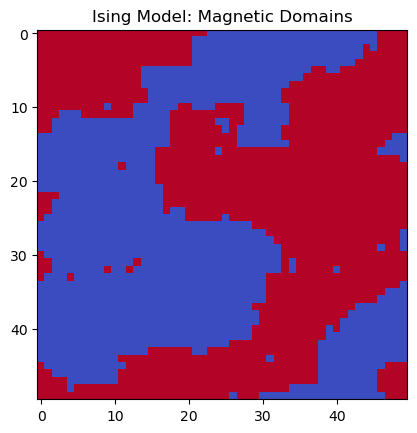

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_ising(size=50, temp=2.26): # 2.26 is the critical 'Curie' temperature
    # Initialize random spins (+1 or -1)
    spins = np.random.choice([-1, 1], size=(size, size))
    
    for _ in range(100000): # Monte Carlo steps
        i, j = np.random.randint(0, size, 2)
        # Calculate energy change if we flip this spin
        neighbor_sum = (spins[(i+1)%size, j] + spins[(i-1)%size, j] +
                        spins[i, (j+1)%size] + spins[i, (j-1)%size])
        dE = 2 * spins[i, j] * neighbor_sum
        
        # Metropolis Algorithm: Flip if energy is lower or by probability
        if dE <= 0 or np.random.rand() < np.exp(-dE / temp):
            spins[i, j] *= -1
            
    return spins

# Simulate at a low temperature (ordered/magnetic)
magnetic_spins = simulate_ising(temp=1.5)

plt.imshow(magnetic_spins, cmap='coolwarm')
plt.title("Ising Model: Magnetic Domains")
plt.savefig('ising_model.png')